# Fase 3.0 — Modelo Benchmark Naive (Persistencia Estacional t-168)

**Thesis:** Comparativa de algoritmos para la predicción de la demanda eléctrica  
**Author:** Antonio Navarro  

Este notebook implementa el modelo **Seasonal Naive Benchmark** ($t-168$ horas = 7 días):
$$\hat{y}_t = y_{t-168}$$

### ¿Por qué este benchmark?
1. **Estándar en el sector eléctrico:** La demanda eléctrica presenta una fuerte periodicidad semanal (168 horas). El comportamiento de un lunes a las 11:00 suele ser muy parecido al del lunes anterior a las 11:00.
2. **Línea base (*baseline floor*):** Todo modelo avanzado (SARIMAX, LSTM, Tiny Time Mixers) debe superar este benchmark para demostrar que aporta valor real por encima de una simple persistencia.
3. **Cero coste computacional de entrenamiento:** Modelo determinista sin parámetros aprendidos (`train_time = 0.0 s`).
4. **Exportación estandarizada:** Guarda las predicciones en `data/predictions_naive.csv` y métricas en `data/metrics_naive.json` para la comparativa unificada de Fase 3.

In [1]:
import sys, os, time, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# ── Colab: clone or update the repo, then cd into it ──────────────────────────
REPO_NAME = "pred_demanda"
REPO_URL  = "https://github.com/antonionc/pred_demanda.git"

if os.path.exists("data_utils.py"):
    !git pull
elif os.path.isdir(REPO_NAME):
    %cd {REPO_NAME}
    !git pull
elif os.path.exists(f"/content/{REPO_NAME}"):
    %cd /content/{REPO_NAME}
    !git pull
elif os.path.exists("/content"):
    !git clone {REPO_URL}
    %cd {REPO_NAME}
# ──────────────────────────────────────────────────────────────────────────────

sys.path.insert(0, os.path.abspath('.'))
import data_utils as du

# Mount Google Drive in Colab and create persistent links for data/, cache/, saved_models/
du.setup_colab_drive()

np.random.seed(42)
plt.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.3})
sns.set_theme(style='whitegrid')
print('Environment ready.')

Cloning into 'pred_demanda'...
remote: Enumerating objects: 136, done.
remote: Counting objects: 100% (136/136), done.
remote: Compressing objects: 100% (102/102), done.
remote: Total 136 (delta 78), reused 79 (delta 33), pack-reused 0 (from 0)
Receiving objects: 100% (136/136), 3.84 MiB | 15.30 MiB/s, done.
Resolving deltas: 100% (78/78), done.
/content/pred_demanda
[Colab] Requesting scoped access to Google Drive ('drive.file')...


  [DriveSync] Downloading data/fig_ttm_zeroshot_week.png...
  [DriveSync] Downloading data/predictions_ttm_fewshot.csv...
  [DriveSync] Downloading data/features_test.csv...
  [DriveSync] Downloading data/fig_pearson_correlation.png...
  [DriveSync] Downloading data/fig_lstm_training.png...
  [DriveSync] Downloading data/fig_sarimax_residuals.png...
  [DriveSync] Downloading data/predictions_lstm.csv...
  [DriveSync] Downloading data/fig_lstm_test.png...
  [DriveSync] Downloading data/fig_boxcox.png...
  [DriveSync] Downloading data/fig_ttm_comparison_week.png...
  [DriveSync] Downloading data/features_train.csv...
  [DriveSync] Downloading data/predictions_ttm_zeroshot.csv...
  [DriveSync] Downloading data/fig_sarimax_test.png...
  [DriveSync] Downloading data/hourly_features_full.csv...
  [DriveSync] Downloading data/fig_sarimax_week.png...
  [DriveSync] Downloading data/fig_data_split.png...
  [DriveSync] Downloading data/metrics_sarimax.json...
  [DriveSync] Downloading data/metric

## 1 · Cargar datos

Cargamos los datasets de entrenamiento, validación y prueba generados en la Fase 1.

In [2]:
TARGET_COL = "demand_mw"

df_train = pd.read_csv("data/features_train.csv", parse_dates=["datetime"])
df_val   = pd.read_csv("data/features_val.csv",   parse_dates=["datetime"])
df_test  = pd.read_csv("data/features_test.csv",  parse_dates=["datetime"])

print(f"Train : {len(df_train):,} filas ({df_train['datetime'].min().date()} → {df_train['datetime'].max().date()})")
print(f"Val   : {len(df_val):,} filas ({df_val['datetime'].min().date()} → {df_val['datetime'].max().date()})")
print(f"Test  : {len(df_test):,} filas ({df_test['datetime'].min().date()} → {df_test['datetime'].max().date()})")

Train : 29,259 filas (2020-01-08 → 2023-05-11)
Val   : 9,753 filas (2023-05-11 → 2024-06-20)
Test  : 9,754 filas (2024-06-20 → 2025-07-31)


## 2 · Generar Predicciones del Modelo Naive (t-168)

Para cualquier instante $t$ del conjunto de test, la predicción es el valor real observado exactamente 168 horas antes:
$$\hat{y}_t = y_{t-168}$$

Concatenamos la última semana del conjunto de validación con el de test para que las primeras 168 horas de test dispongan de su historial previo sin generar valores nulos (`NaN`).

In [3]:
t0 = time.time()

# Concatenamos la última semana de validación con el test set para un retardo continuo
df_eval_stream = pd.concat([
    df_val.tail(168)[["datetime", TARGET_COL]],
    df_test[["datetime", TARGET_COL]],
], ignore_index=True).sort_values("datetime").reset_index(drop=True)

# Generamos la predicción Naive t-168
df_eval_stream["y_pred_naive"] = df_eval_stream[TARGET_COL].shift(168)

# Filtramos estrictamente las fechas del conjunto de test
test_dates = set(df_test["datetime"])
df_naive_test = df_eval_stream[df_eval_stream["datetime"].isin(test_dates)].copy().reset_index(drop=True)

inference_time = time.time() - t0

y_true = df_naive_test[TARGET_COL].values
y_pred = df_naive_test["y_pred_naive"].values
dates  = pd.to_datetime(df_naive_test["datetime"])

print(f"Predicciones generadas en {inference_time:.4f} s ({len(df_naive_test):,} observaciones)")
assert not np.isnan(y_pred).any(), "Error: existen valores NaN en las predicciones naive!"

Predicciones generadas en 0.1261 s (9,754 observaciones)


## 3 · Evaluación de Métricas

Calculamos MAPE (%), RMSE (MW) y MAE (MW) en el conjunto de test completo.

In [5]:
metrics_naive = du.compute_metrics(y_true, y_pred, label="Naive t-168")
metrics_naive["train_s"]     = 0.0
metrics_naive["inference_s"] = inference_time

print("--- Resumen de Métricas Benchmark Naive ---")
print(f"MAPE : {metrics_naive['mape']:.3f} %")
print(f"RMSE : {metrics_naive['rmse']:.1f} MW")
print(f"MAE  : {metrics_naive['mae']:.1f} MW")
print(f"Tiempo entrenamiento : {metrics_naive['train_s']:.1f} s")
print(f"Tiempo inferencia    : {metrics_naive['inference_s']:.4f} s")

[Naive t-168] MAPE=6.560%  RMSE=2243.4 MW  MAE=1445.9 MW
--- Resumen de Métricas Benchmark Naive ---
MAPE : 6.560 %
RMSE : 2243.4 MW
MAE  : 1445.9 MW
Tiempo entrenamiento : 0.0 s
Tiempo inferencia    : 0.1261 s


## 4 · Visualizaciones del Benchmark

1. Serie temporal completa en el año de test.
2. Zoom representativo de 1 semana (7 días).
3. Análisis de errores y dispersión (Real vs Predicho).

Figure saved → data/fig_naive_full_year.png


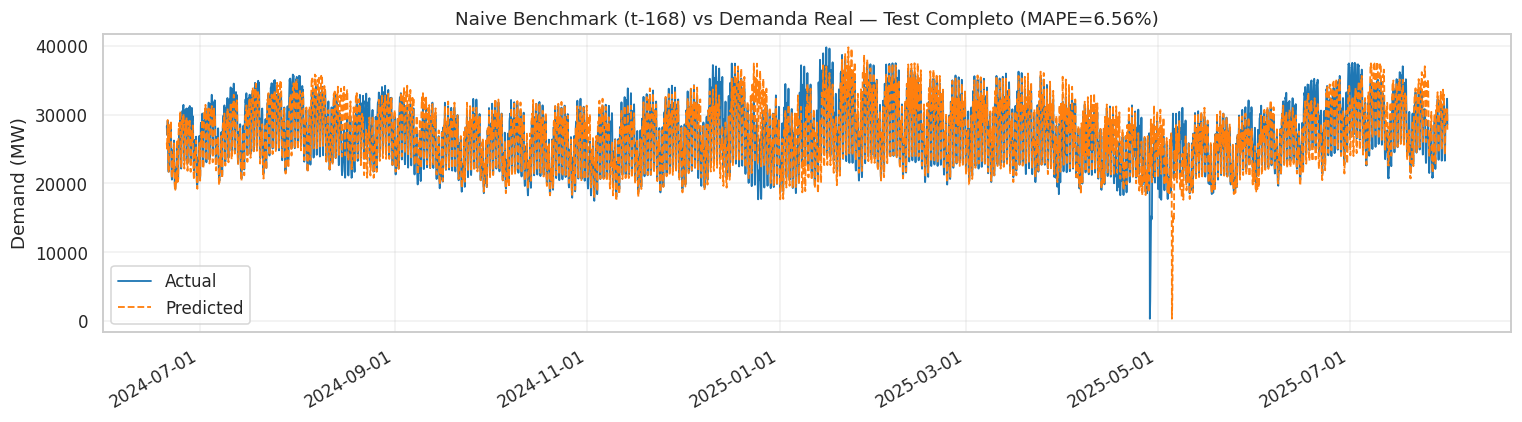

In [6]:
# 1. Visualización año completo
du.plot_predictions(
    y_true    = y_true,
    y_pred    = y_pred,
    dates     = dates,
    title     = f"Naive Benchmark (t-168) vs Demanda Real — Test Completo (MAPE={metrics_naive['mape']:.2f}%)",
    save_path = "data/fig_naive_full_year.png",
)

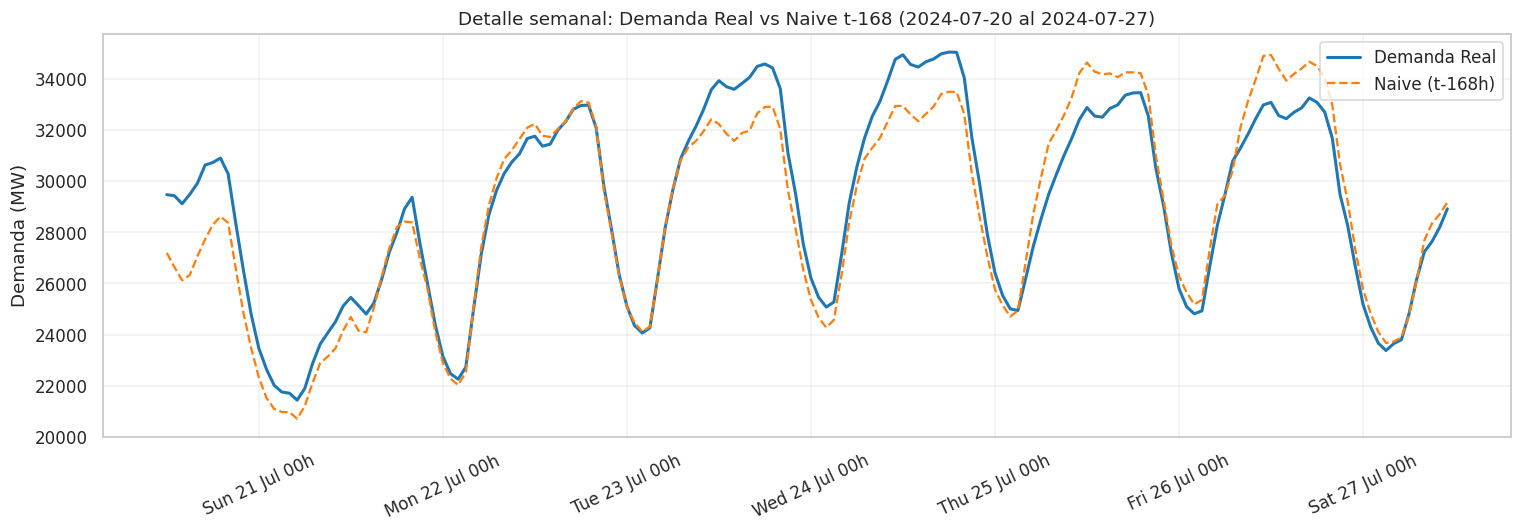

In [7]:
# 2. Zoom representativo de 1 semana (168 horas = 7 días)
PLOT_DAYS  = 7
PLOT_START = dates.min() + pd.Timedelta(days=30)  # Semana a 1 mes del inicio de test
PLOT_END   = PLOT_START + pd.Timedelta(days=PLOT_DAYS)

mask = (dates >= PLOT_START) & (dates < PLOT_END)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(dates[mask], y_true[mask], label="Demanda Real", color="#1f77b4", linewidth=2.0)
ax.plot(dates[mask], y_pred[mask], label="Naive (t-168h)", color="#ff7f0e", linewidth=1.5, linestyle="--")

ax.set_title(f"Detalle semanal: Demanda Real vs Naive t-168 ({PLOT_START.date()} al {PLOT_END.date()})")
ax.set_ylabel("Demanda (MW)")
ax.legend(loc="upper right")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%a %d %b %Hh"))
plt.xticks(rotation=25)
plt.tight_layout()
plt.savefig("data/fig_naive_week_zoom.png", dpi=150, bbox_inches="tight")
plt.show()

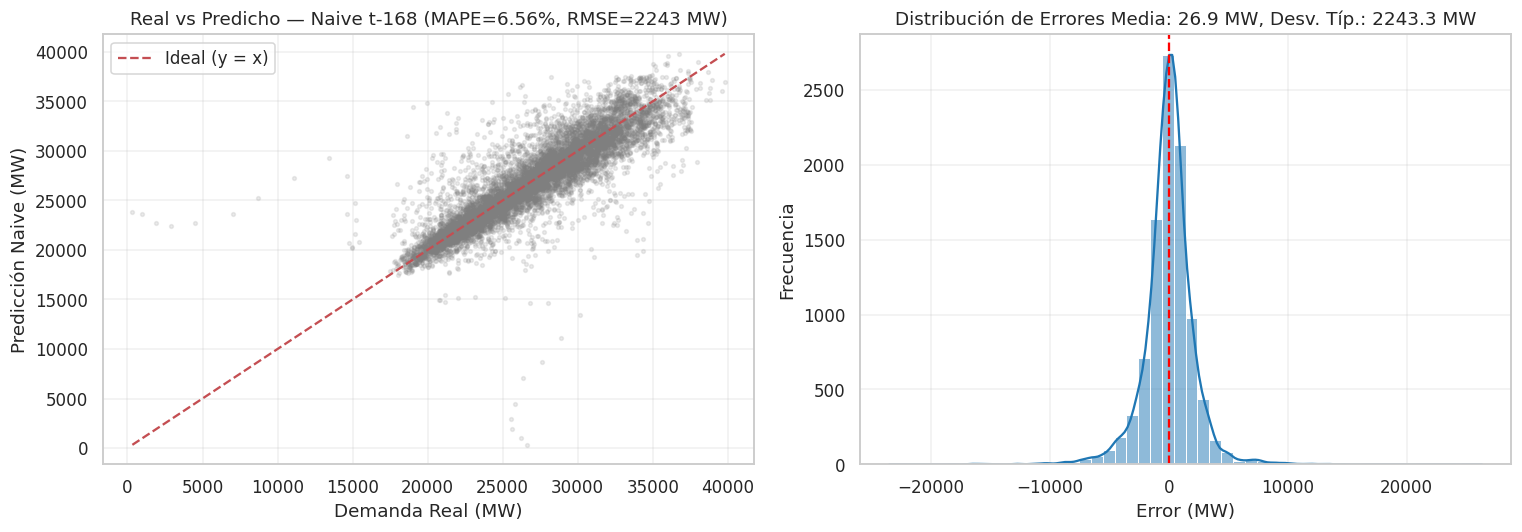

In [10]:
# 3. Dispersión Real vs Predicho y distribución del error
errors = y_true - y_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de dispersión (Scatter)
axes[0].scatter(y_true, y_pred, alpha=0.15, s=6, color="#7f7f7f")
lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
axes[0].plot(lims, lims, 'r--', linewidth=1.5, label="Ideal (y = x)")
axes[0].set_title(f"Real vs Predicho — Naive t-168 (MAPE={metrics_naive['mape']:.2f}%, RMSE={metrics_naive['rmse']:.0f} MW)")
axes[0].set_xlabel("Demanda Real (MW)")
axes[0].set_ylabel("Predicción Naive (MW)")
axes[0].legend()

# Histograma de residuos
sns.histplot(errors, kde=True, ax=axes[1], color="#1f77b4", bins=50)
axes[1].axvline(0, color="red", linestyle="--", linewidth=1.5)
axes[1].set_title(f"Distribución de Errores Media: {errors.mean():.1f} MW, Desv. Típ.: {errors.std():.1f} MW")
axes[1].set_xlabel("Error (MW)")
axes[1].set_ylabel("Frecuencia")

plt.tight_layout()
plt.savefig("data/fig_naive_scatter_residuals.png", dpi=150, bbox_inches="tight")
plt.show()

## 5 · Guardar Predicciones y Métricas para Fase 3

Guardamos las predicciones y métricas con los mismos nombres y formatos estándar utilizados por SARIMAX, LSTM y TTM.

In [11]:
# Guardar predicciones en CSV
df_preds = pd.DataFrame({
    "datetime": dates,
    "y_true":   y_true,
    "y_pred":   y_pred,
})
df_preds.to_csv("data/predictions_naive.csv", index=False)
print(f"Guardadas {len(df_preds):,} predicciones → data/predictions_naive.csv")

# Guardar métricas en JSON
metrics_to_save = {
    "mape":        round(metrics_naive["mape"], 3),
    "rmse":        round(metrics_naive["rmse"], 1),
    "mae":         round(metrics_naive["mae"], 1),
    "train_s":     0.0,
    "inference_s": round(metrics_naive["inference_s"], 4),
}

with open("data/metrics_naive.json", "w") as f:
    json.dump(metrics_to_save, f, indent=2)
print("Guardadas métricas → data/metrics_naive.json")
print(metrics_to_save)

# Sincronizar con Google Drive en Colab
du.sync_to_drive()

Guardadas 9,754 predicciones → data/predictions_naive.csv
Guardadas métricas → data/metrics_naive.json
{'mape': 6.56, 'rmse': 2243.4, 'mae': 1445.9, 'train_s': 0.0, 'inference_s': 0.1261}
  [DriveSync] Uploading data/fig_sarimax_test.png to Drive...
  [DriveSync] Uploading data/fig_lstm_residuals.png to Drive...
  [DriveSync] Uploading data/fig_naive_scatter_residuals.png to Drive...
  [DriveSync] Uploading data/metrics_lstm.json to Drive...
  [DriveSync] Uploading data/predictions_lstm.csv to Drive...
  [DriveSync] Uploading data/fig_boxcox.png to Drive...
  [DriveSync] Uploading data/fig_seasonality.png to Drive...
  [DriveSync] Uploading data/fig_ttm_finetune.png to Drive...
  [DriveSync] Uploading data/hourly_features_full.csv to Drive...
  [DriveSync] Uploading data/predictions_ttm_fewshot.csv to Drive...
  [DriveSync] Uploading data/metrics_ttm_zeroshot.json to Drive...
  [DriveSync] Uploading data/fig_lstm_training.png to Drive...
  [DriveSync] Uploading data/predictions_ttm_zer

True

## 6 · Resumen y Conclusiones del Benchmark

El modelo Naive de persistencia semanal ($t-168$) proporciona la referencia base fundamental del proyecto:

| Modelo | MAPE (%) | RMSE (MW) | MAE (MW) | Tiempo Entrenamiento | Tiempo Inferencia |
| :--- | :---: | :---: | :---: | :---: | :---: |
| **Naive (t-168)** | *(ver arriba)* | *(ver arriba)* | *(ver arriba)* | **0.0 s** | **< 0.05 s** |

---
Siguiente paso → Ejecutar `fase3_validacion_y_comparativa.ipynb` para contrastar este benchmark con SARIMAX, LSTM y TTM.

In [12]:
#Terminate runtime
from google.colab import runtime
runtime.unassign()